# GLIMS
## Fetch les données brutes
### Une fois téléchargées, elles seront dans /projet_glacier/data/raw/...

In [1]:
from glacier.data import fetch_data, unzip_to
paths = fetch_data("20260114")

#### Dézippe les fichiers téléchargers


In [2]:
paths = fetch_data("20260114")
extracted_root = paths[0].parent / "extracted"
extracted_dirs = unzip_to(paths, extracted_root)

## Exploration du jeu de donnée brute

In [3]:
from pathlib import Path
from glacier.data.data_fetching import repo_root
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
root = repo_root()
base = root / "data" / "raw" / "glims_v1" / "extracted"

north = next(p for p in base.rglob("glims_polygons.shp") if "_north_" in str(p).lower())
south = next(p for p in base.rglob("glims_polygons.shp") if "_south_" in str(p).lower())

gdf_raw_north = gpd.read_file(north)
gdf_raw_south = gpd.read_file(south)
gdf_raw = pd.concat([gdf_raw_north, gdf_raw_south])
len(gdf_raw), gdf_raw.crs #.crs est pour vérifier le système de coordonnéees 

C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\data\raw\glims_v1\extracted\NSIDC-0272_glims_db_north_20260114_v01.0\glims_download_73053\glims_polygons.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\data\raw\glims_v1\extracted\NSIDC-0272_glims_db_south_20260114_v01.0\glims_download_05601\glims_polygons.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


(785920,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [5]:
gdf_raw.columns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
gdf_raw.head(5)

,line_type,anlys_id,glac_id,anlys_time,area,db_area,width,length,primeclass,min_elev,mean_elev,max_elev,src_date,rec_status,glac_name,wgms_id,local_id,glac_stat,gone_date,gone_dt_e,subm_id,release_dt,proc_desc,rc_id,geog_area,chief_affl,conn_lvl,surge_type,term_type,gtng_o1reg,gtng_o2reg,rgi_gl_typ,parent_id,submitters,analysts,geometry
0,glac_bound,715234.0,G340953E63564N,1993-09-01T00:00:00,12.414,12.413600,0.0,0.0,0.0,405.0,0.0,1440.0,1999-09-09T00:00:00,okay,None,None,None,exists,None,0.0,719.0,2014-12-01T11:00:00,Manual glacier digitization from ASTER imagery...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,6.0,1.0,None,G340925E63656N,"Sigurdsson, Oddur","Sigurdsson, Oddur","POLYGON ((-19.04472 63.58378, -19.04474 63.583..."
1,glac_bound,1048878.0,G306386E70153N,2020-09-09T00:00:00,0.000,14.933000,0.0,0.0,0.0,0.0,0.0,0.0,1900-09-09T00:00:00,okay,None,None,None,exists,None,0.0,830.0,2020-08-25T09:00:00,Mapping of Little Ice Age morraines; Mapped mo...,586.0,Greenland,University of Leeds,0.0,0.0,0.0,5.0,1.0,None,None,"Carrivick, Jonathan L.","Carrivick, Jonathan L.","POLYGON ((-53.67435 70.18178, -53.66553 70.180..."
2,glac_bound,409177.0,G222822E58665N,2015-07-16T00:00:00,0.777,0.776922,0.0,0.0,0.0,2496.0,0.0,3879.0,2010-09-15T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,1.0,9.0,1.0,6.0,19,G222793E58546N,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-137.17153 58.66963, -137.17016 58.6..."
3,glac_bound,405377.0,G217968E60885N,2015-07-16T00:00:00,8.838,8.837740,0.0,0.0,0.0,1560.0,0.0,2410.0,2010-09-12T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,1.0,5.0,99,None,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-141.99826 60.87683, -141.99836 60.8..."
4,glac_bound,401811.0,G214518E60704N,2015-07-16T00:00:00,0.258,0.258463,0.0,0.0,0.0,600.0,0.0,1147.0,2010-09-02T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,1.0,4.0,99,None,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-145.47844 60.70451, -145.47778 60.7..."


In [6]:
gdf_raw.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 785920 entries, 0 to 169128
Data columns (total 36 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   line_type   785920 non-null  object  
 1   anlys_id    785920 non-null  float64 
 2   glac_id     785920 non-null  object  
 3   anlys_time  785920 non-null  object  
 4   area        785920 non-null  float64 
 5   db_area     785920 non-null  float64 
 6   width       785920 non-null  float64 
 7   length      785920 non-null  float64 
 8   primeclass  785920 non-null  float64 
 9   min_elev    785920 non-null  float64 
 10  mean_elev   785920 non-null  float64 
 11  max_elev    785920 non-null  float64 
 12  src_date    785920 non-null  object  
 13  rec_status  785920 non-null  object  
 14  glac_name   785812 non-null  object  
 15  wgms_id     785920 non-null  object  
 16  local_id    785906 non-null  object  
 17  glac_stat   785920 non-null  object  
 18  gone_date   785920 no

In [7]:
gdf_raw[["min_elev","mean_elev","max_elev"]].describe()

,min_elev,mean_elev,max_elev
count,785920.000000,785920.000000,785920.000000
mean,1535.592125,904.086997,1751.315117
std,2110.262705,1849.328963,2263.616172
min,-9999.000000,-9999.000000,-9999.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,3486.000000,348.000000,3734.000000
max,8047.000000,8115.000000,65535.000000


In [8]:
df_raw = pd.DataFrame(gdf_raw.drop(columns="geometry")) # moins lourd pour certains graphes

df = df_raw.copy()
df["src_date_dt"] = pd.to_datetime(df["src_date"], errors="coerce")

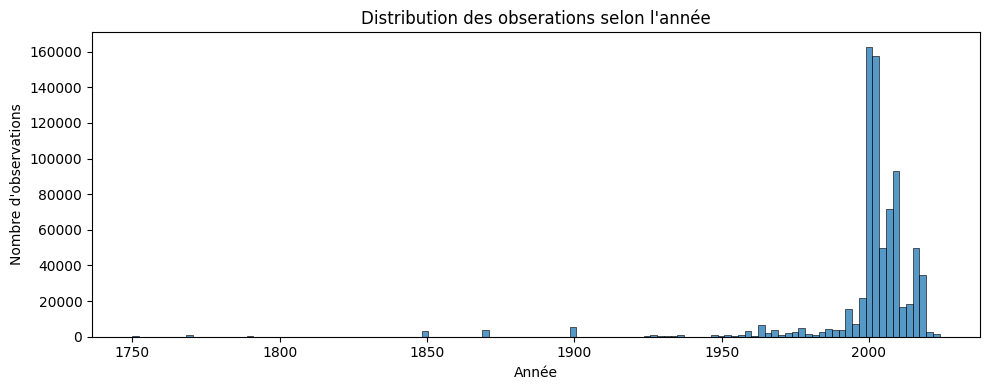

In [9]:
years = df["src_date_dt"].dt.year

plt.figure(figsize=(10,4))
sns.histplot(years.dropna(), bins=120)
plt.title("Distribution des obserations selon l'année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

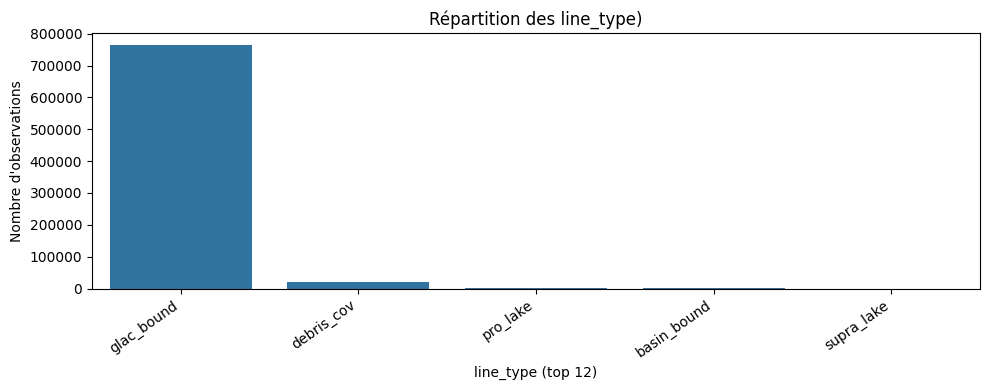

In [10]:
plt.figure(figsize=(10,4))
order = df["line_type"].value_counts().head(10).index  # top 10 si jamais il y en a beaucoup
sns.countplot(data=df, x="line_type", order=order)
plt.title("Répartition des line_type)")
plt.xlabel("line_type (top 12)")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

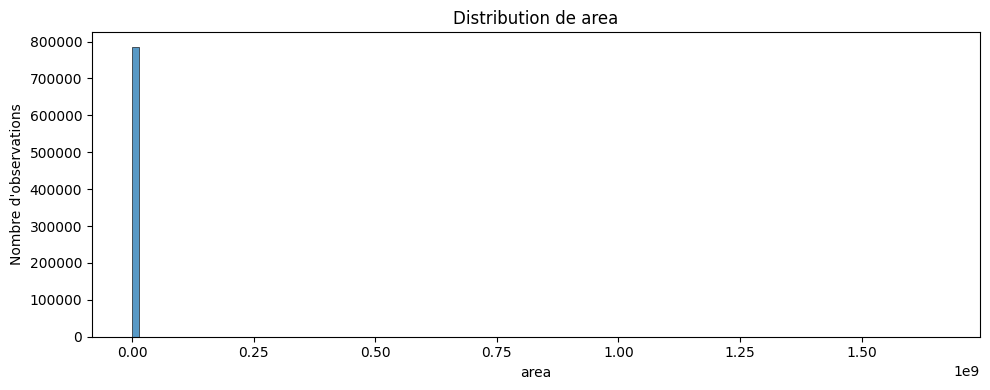

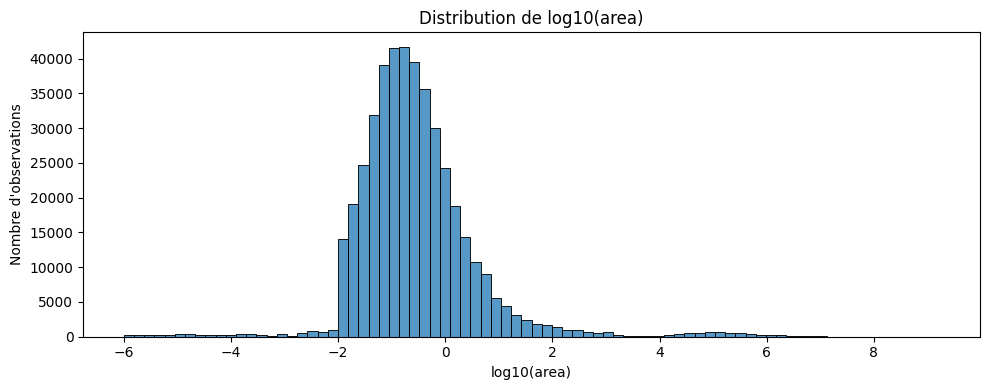

In [11]:
if "area" in df.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df["area"], bins=120)
    plt.title("Distribution de area")
    plt.xlabel("area")
    plt.ylabel("Nombre d'observations")
    plt.tight_layout()
    plt.show()

    # version log (plus lisible si très skew)
    positive = df["area"].where(df["area"] > 0)
    plt.figure(figsize=(10,4))
    sns.histplot(np.log10(positive.dropna()), bins=80)
    plt.title("Distribution de log10(area)")
    plt.xlabel("log10(area)")
    plt.ylabel("Nombre d'observations")
    plt.tight_layout()
    plt.show()

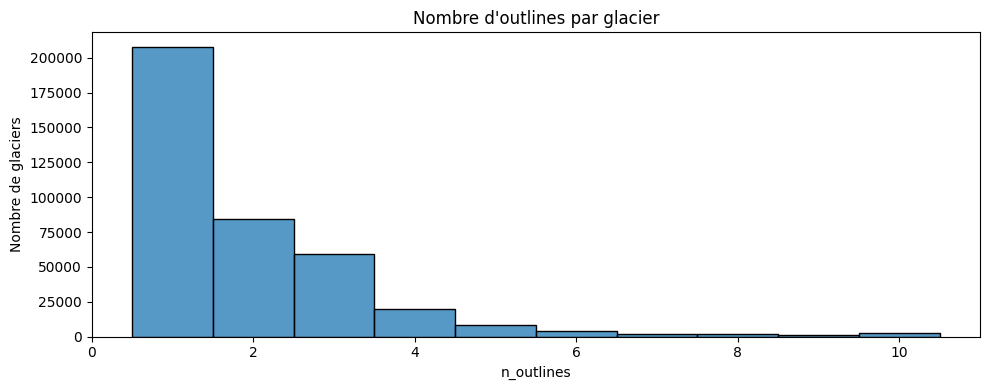

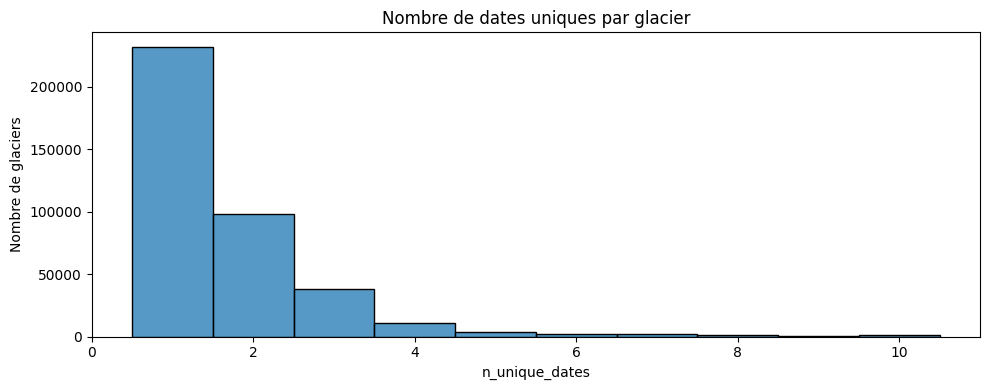

In [12]:
tmp = df.dropna(subset=["glac_id"]).copy()
n_outlines = tmp.groupby("glac_id").size()

tmp2 = tmp.dropna(subset=["src_date_dt"])
n_dates = tmp2.groupby("glac_id")["src_date_dt"].nunique()

cap = 10

plt.figure(figsize=(10,4))
sns.histplot(n_outlines.clip(upper=cap), bins=cap, discrete=True)
plt.title("Nombre d'outlines par glacier")
plt.xlabel("n_outlines")
plt.ylabel("Nombre de glaciers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(n_dates.clip(upper=cap), bins=cap, discrete=True)
plt.title("Nombre de dates uniques par glacier")
plt.xlabel("n_unique_dates")
plt.ylabel("Nombre de glaciers")
plt.tight_layout()
plt.show()

# Nettoyage du jeu de données
## Une fois téléchargées, elles seront dans /projet_glacier/data/processed/...
Pour voir précisément comment les nettoyage est fait, il est possible de consulter le fichier
src/glacier/data/data_cleaning.py.
Pour faire court, le nettoyage du jeu de données consiste à :
- Conserver uniquement les contours de glaciers pertinents (line_type = "glac_bound").
- Nettoyer les géométries (retirer les géométries vides/nulles, définir le CRS et corriger les géométries invalides) pour fiabiliser les opérations spatiales. (il y en a quasiment aucunes mais juste au cas où)
- Recoder les valeurs sentinelles (p. ex. -9999) des variables d’élévation en valeurs manquantes (NaN) sans supprimer d’observations.
- Supprimer les valeurs non physiques (aire ≤ 0) et les doublons exacts.

Ensuite nous filtrons de façons à garder que ce qui semble exploitable pour pouvoir faire de la prédiction

- Nous filtrons les glaciers disposant d’au moins $k\geq 2$ dates d’observation distinctes afin de disposer d’une information temporelle suffisante
- Convertir src_date en datetime et gérer les valeurs aberrantes; le filtrage temporel (p. ex. ≥1900 ou ≥2015) est appliqué dans une vue dédiée à l’analyse temporelle.

In [13]:
from glacier.data import fetch_data, clean_glims_outlines, make_temporal_view

In [14]:
gdf_north = clean_glims_outlines(gdf_raw_north)
gdf_south = clean_glims_outlines(gdf_raw_south)
gdf = gpd.GeoDataFrame(pd.concat([gdf_north, gdf_south], ignore_index=True), crs=gdf_north.crs)


C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\src\glacier\data\data_cleaning.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gdf["src_date_dt"] = pd.to_datetime(gdf[col], errors="coerce", utc=True)


In [15]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

gdf.head()

,line_type,anlys_id,glac_id,anlys_time,area,db_area,width,length,primeclass,min_elev,mean_elev,max_elev,src_date,rec_status,glac_name,wgms_id,local_id,glac_stat,gone_date,gone_dt_e,subm_id,release_dt,proc_desc,rc_id,geog_area,chief_affl,conn_lvl,surge_type,term_type,gtng_o1reg,gtng_o2reg,rgi_gl_typ,parent_id,submitters,analysts,geometry,src_date_dt
0,glac_bound,715234.0,G340953E63564N,1993-09-01 00:00:00+00:00,12.414,12.413600,0.0,0.0,0.0,405.0,0.0,1440.0,1999-09-09T00:00:00,okay,None,None,None,exists,None,0.0,719.0,2014-12-01T11:00:00,Manual glacier digitization from ASTER imagery...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,6.0,1.0,None,G340925E63656N,"Sigurdsson, Oddur","Sigurdsson, Oddur","POLYGON ((-19.04472 63.58378, -19.04474 63.583...",1999-09-09 00:00:00+00:00
1,glac_bound,409177.0,G222822E58665N,2015-07-16 00:00:00+00:00,0.777,0.776922,0.0,0.0,0.0,2496.0,0.0,3879.0,2010-09-15T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,1.0,9.0,1.0,6.0,19,G222793E58546N,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-137.17153 58.66963, -137.17016 58.6...",2010-09-15 00:00:00+00:00
2,glac_bound,405377.0,G217968E60885N,2015-07-16 00:00:00+00:00,8.838,8.837740,0.0,0.0,0.0,1560.0,0.0,2410.0,2010-09-12T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,1.0,5.0,99,None,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-141.99826 60.87683, -141.99836 60.8...",2010-09-12 00:00:00+00:00
3,glac_bound,401811.0,G214518E60704N,2015-07-16 00:00:00+00:00,0.258,0.258463,0.0,0.0,0.0,600.0,0.0,1147.0,2010-09-02T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,1.0,4.0,99,None,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-145.47844 60.70451, -145.47778 60.7...",2010-09-02 00:00:00+00:00
4,glac_bound,414761.0,G227911E56819N,2015-07-16 00:00:00+00:00,0.260,0.260388,0.0,0.0,0.0,1203.0,0.0,1399.0,2004-08-10T00:00:00,okay,None,None,None,exists,None,0.0,624.0,2015-07-16T00:00:00,Semi-automated glacier classification.; From R...,761.0,Randolph Glacier Inventory; Umbrella RC for me...,University of Colorado,0.0,0.0,9.0,1.0,6.0,99,None,"Cogley, Graham","Beedle, Matthew; Berthier, Etienne; Bolch, Tob...","POLYGON ((-132.08464 56.82164, -132.0858 56.81...",2004-08-10 00:00:00+00:00


In [16]:
print("raw north:", len(gdf_raw_north), "-> clean:", len(gdf_north)) 
print("raw south:", len(gdf_raw_south), "-> clean:", len(gdf_south))
print("total clean:", len(gdf))
gdf.info()

raw north: 616791 -> clean: 293728
raw south: 169129 -> clean: 107152
total clean: 400880
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 400880 entries, 0 to 400879
Data columns (total 37 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   line_type    400880 non-null  object             
 1   anlys_id     400880 non-null  float64            
 2   glac_id      400880 non-null  object             
 3   anlys_time   400880 non-null  datetime64[ns, UTC]
 4   area         400880 non-null  float64            
 5   db_area      400880 non-null  float64            
 6   width        400880 non-null  float64            
 7   length       400880 non-null  float64            
 8   primeclass   400880 non-null  float64            
 9   min_elev     400749 non-null  float64            
 10  mean_elev    400741 non-null  float64            
 11  max_elev     400749 non-null  float64            
 12  src_date     400

In [17]:
gdf[["min_elev","mean_elev","max_elev"]].describe()

,min_elev,mean_elev,max_elev
count,400749.000000,400741.000000,400749.000000
mean,2125.146985,918.412471,2410.393269
std,2095.087216,1707.332512,2213.204632
min,-66.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1347.000000,0.000000,1746.000000
75%,4289.000000,1110.000000,4681.000000
max,8047.000000,8115.000000,65535.000000


In [18]:
temporal = make_temporal_view(gdf, min_date="1900-01-01")

In [19]:
root = repo_root()
proc = root / "data" / "processed"
proc.mkdir(parents=True, exist_ok=True)

(gdf).to_parquet(proc / "glims_base.parquet")
temporal.to_parquet(proc / "glims_temporal_1900.parquet")

# (pred).to_parquet(proc / "glims_pred_1900.parquet")
# (pred_s2).to_parquet(proc / "glims_pred_s2.parquet")

### pour recuperer les jeu de données dans les prochains notebook sans tout rerun on fera 
# gdf = gpd.read_parquet(proc / "glims_base.parquet")
# pred = gpd.read_parquet(proc / "glims_pred_1900.parquet")
# pred_s2 = gpd.read_parquet(proc / "glims_pred_s2.parquet")

# Sentinel-2
Avec les images satellitaires, on fait attention à deux points :
- éviter de télécharger des scènes entières (trop volumineuses) en ne conservant que des découpes autour de chaque glacier et quelques bandes utiles;
- limiter le bruit dû aux nuages/ombres et à la neige saisonnière. Pour cela, on se concentre sur la période estivale (p. ex. juin–septembre) et on construit, pour chaque glacier et chaque année, une composition médiane des observations estivales, ce qui réduit l’impact des pixels nuageux résiduels et stabilise les entrées du modèle.

On commencera aussi avec un nombre peu élevé de glaciers et si tout fonctionne bien on généralisera avec un plus grand nombre de glaciers. Nous allons donc considérer les glaciers de certaines régions uniquement pour l'instant, puisque le but est de faire de la segmentation et que nous souhaitons aussi évaluer la robustesse vis-à-vis l'emplacement nous allons entrainé le modèle sur les alpes et ensuite tester sur une région similaire la Caucase et une région plus différente les Andes.

In [20]:
# Commençons alors par filtrer le datafram glims pour avoir que les glaciers des régions mentionnées
from glacier.data import filter_regions

temporal_reg = filter_regions(temporal)  # alps + caucasus + andes
temporal_reg.to_parquet(proc / "glims_temporal_regions.parquet")

C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\src\glacier\data\data_cleaning.py:180: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = gdf.geometry.centroid


In [21]:
root = repo_root()
temporal_reg = gpd.read_parquet(root / "data" / "processed"/ "glims_temporal_regions.parquet")
temporal_reg

,glac_id,src_date_dt,geometry,area,region
53,G005930E45041N,1985-09-28 00:00:00+00:00,"POLYGON ((5.9297 45.03937, 5.92967 45.04018, 5...",0.031139,alps
54,G005930E45041N,2003-08-13 00:00:00+00:00,"POLYGON ((5.93134 45.03982, 5.93137 45.03956, ...",0.009568,alps
55,G005930E45041N,2003-09-21 00:00:00+00:00,"POLYGON ((5.93134 45.03982, 5.93137 45.03956, ...",0.009600,alps
56,G005936E45041N,1985-09-28 00:00:00+00:00,"POLYGON ((5.93502 45.04005, 5.935 45.04031, 5....",0.015077,alps
57,G005936E45041N,2003-08-13 00:00:00+00:00,"POLYGON ((5.93574 45.04022, 5.93512 45.04016, ...",0.003100,alps
...,...,...,...,...,...
335974,G293989E27091S,2010-06-06 00:00:00+00:00,"POLYGON ((-66.01048 -27.08924, -66.0103 -27.08...",0.046900,andes
335975,G293989E27099S,2010-06-06 00:00:00+00:00,"POLYGON ((-66.01164 -27.09617, -66.01156 -27.0...",0.128800,andes
335979,G293991E27133S,2012-06-20 00:00:00+00:00,"POLYGON ((-66.0084 -27.13401, -66.00826 -27.13...",0.047100,andes
335991,G293997E27076S,2010-06-06 00:00:00+00:00,"POLYGON ((-65.99753 -27.07934, -65.99808 -27.0...",0.238400,andes


Nous n'allons pas chercher 106788 images satellites, trouvons d'abord toutes ces données correspondent à combien de glac_id individuels en gardant que leur contour le plus récent et 68645 reste trop. Pour downsample ceci nous allons considérers que les plus gros glaciers.

In [22]:
temporal_sorted = temporal_reg.sort_values("src_date_dt")
glaciers_ref = temporal_sorted.drop_duplicates("glac_id", keep="last").copy()
print("Nb glaciers uniques:", glaciers_ref["glac_id"].nunique())

Nb glaciers uniques: 68645


In [23]:
glaciers_ref = glaciers_ref[glaciers_ref["area"] >= 0.05].copy()
glaciers_ref

,glac_id,src_date_dt,geometry,area,region
29665,G042539E43321N,1960-01-01 00:00:00+00:00,"POLYGON ((42.53895 43.32179, 42.53896 43.32178...",0.052682,caucasus
29692,G042544E43118N,1960-01-01 00:00:00+00:00,"POLYGON ((42.54154 43.11739, 42.54155 43.1177,...",0.123296,caucasus
29741,G042555E43098N,1960-01-01 00:00:00+00:00,"POLYGON ((42.56158 43.09961, 42.56214 43.09919...",0.170049,caucasus
29729,G042553E43113N,1960-01-01 00:00:00+00:00,"POLYGON ((42.54839 43.11372, 42.54834 43.11376...",0.172461,caucasus
29722,G042551E43122N,1960-01-01 00:00:00+00:00,"POLYGON ((42.55238 43.12255, 42.55206 43.12238...",0.051264,caucasus
...,...,...,...,...,...
30880,G042916E43171N,2020-09-11 00:00:00+00:00,"POLYGON ((42.91008 43.16956, 42.90987 43.16978...",0.270697,caucasus
31940,G043272E42918N,2020-09-11 00:00:00+00:00,"POLYGON ((43.27264 42.91938, 43.2728 42.91947,...",0.061253,caucasus
31944,G043274E42960N,2020-09-11 00:00:00+00:00,"POLYGON ((43.27225 42.96076, 43.2724 42.9609, ...",0.071869,caucasus
31951,G043276E43053N,2020-09-11 00:00:00+00:00,"POLYGON ((43.28637 43.04567, 43.28622 43.04561...",2.961240,caucasus


On sample initiallement le nombre de glaciers que l'on souhaite par region

In [24]:

SEED = 0
YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

glaciers_ref = glaciers_ref.copy()
glaciers_ref["year_img"] = None

rng = np.random.default_rng(SEED)
for reg in glaciers_ref["region"].unique():
    idx = glaciers_ref.index[glaciers_ref["region"] == reg].to_numpy()
    y_assigned = np.resize(np.array(YEARS), idx.shape[0])
    rng.shuffle(y_assigned)
    glaciers_ref.loc[idx, "year_img"] = y_assigned

glaciers_ref["year_img"] = glaciers_ref["year_img"].astype(int)

In [25]:
MAX_GAP = 3

gl = temporal_reg[["glac_id","region","src_date_dt","geometry","area"]].copy()
gl["glac_id"] = gl["glac_id"].astype(str).str.strip()
gl["src_year"] = gl["src_date_dt"].dt.year

s = glaciers_ref[["glac_id","region","year_img"]].copy()
s["glac_id"] = s["glac_id"].astype(str).str.strip()

m = s.merge(gl, on=["glac_id","region"], how="left")
m["gap"] = (m["src_year"] - m["year_img"]).abs()

closest = (m.sort_values(["glac_id","gap"])
            .drop_duplicates("glac_id", keep="first")
            .copy())

pool = closest[closest["gap"] <= MAX_GAP].copy()
print(pool["gap"].describe())

count    2759.000000
mean        2.343603
std         1.035670
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: gap, dtype: float64


In [26]:
quota = {"alps": 300, "caucasus": 200, "andes": 100}
parts = []
for reg, n in quota.items():
    sub = pool[pool["region"] == reg]
    parts.append(sub.sample(n=min(n, len(sub)), random_state=SEED))

sampled_final = pd.concat(parts, ignore_index=True)

Cherchons maintenant les images Sentinel 2 pour ce nombre plus raisonable de glaciers.

Pour l'instant on ne fera pas grand chose pour deal avec les nuages et la neige on fera un cleaning plus en detail avec des filtres pour ceci dans un autre notebook.

In [27]:
from glacier.data import build_requests, run_fetch

root = repo_root()
out_root = root / "data" / "sentinel2"
proc = root / "data" / "processed"

split_map = {"alps": "train", "caucasus": "test_near", "andes": "test_far"}

requests = build_requests(sampled_final, out_root=out_root, split_map=split_map, buffer_deg=0.02)
requests.to_parquet(proc / "requests_s2.parquet", index=False)

status = run_fetch(
    requests,
    months=(6,7,8,9),
    bands=("blue","green","red","nir"),
    resolution=10,
    max_cloud=60,
    limit=15,
    reducer="first",
)

(out_root / "logs").mkdir(parents=True, exist_ok=True)
status.to_csv(out_root / "logs" / "fetch_status.csv", index=False)

status["status"].value_counts()

status
ok       415
error      3
Name: count, dtype: int64

# Apperçu d'une des images

Showing: C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\data\sentinel2\composites\train\alps\G007077E44671N_2019_summer.tif


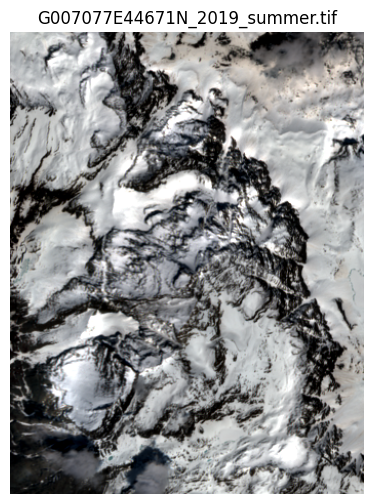

In [28]:
import rioxarray as rxr
base = root / "data" / "sentinel2" / "composites" / "train" / "alps"
p = sorted(base.glob("*.tif"))[0]
print("Showing:", p)

da = rxr.open_rasterio(p).astype("float32")
img_crs = da.rio.crs  # on le réutilise après
# stretch simple (2-98 percentile) pour bien voir
def stretch(x):
    lo, hi = np.nanpercentile(x, 2), np.nanpercentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

blue  = stretch(da[0].values)
green = stretch(da[1].values)
red   = stretch(da[2].values)

rgb = np.stack([red, green, blue], axis=-1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.title(p.name)
plt.show()

## Maintenant pour ce même glacier, observons son contour dans GLIMS et essayons de superposer les deux


glac_id: G007077E44671N
           glac_id  src_year  year_img  gap
66  G007077E44671N      2016      2019    3


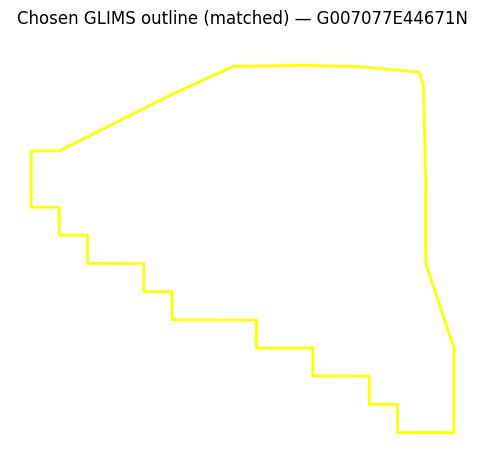

In [31]:
glac_id = p.stem.split("_")[0].strip()
print("glac_id:", glac_id)

g = sampled_final[sampled_final["glac_id"] == glac_id].copy()

if len(g) == 0:
    raise ValueError(
        "Ce glacier n'est pas dans sampled_final. "
        "Probablement que ce .tif vient d'un ancien run (ou out_root différent)."
    )

print(g[["glac_id","src_year","year_img","gap"]])
g = gpd.GeoDataFrame(g, geometry="geometry", crs=4326)
if g.crs is None:
    g = g.set_crs(4326)

g = g.to_crs(img_crs)

fig, ax = plt.subplots(figsize=(6,6))
g.boundary.plot(ax=ax, color="yellow", linewidth=2)
ax.set_title(f"Chosen GLIMS outline (matched) — {glac_id}")
ax.axis("off")
plt.show()

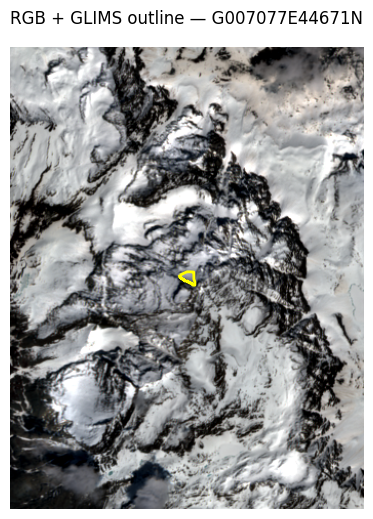

In [32]:
minx, miny, maxx, maxy = da.rio.bounds()

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(rgb, extent=[minx, maxx, miny, maxy], origin="upper")
g.boundary.plot(ax=ax, color="yellow", linewidth=2)
ax.set_title(f"RGB + GLIMS outline — {glac_id}")
ax.axis("off")
plt.show()

In [37]:
from shapely.geometry import box

minx, miny, maxx, maxy = da.rio.bounds()
patch_box = gpd.GeoDataFrame(geometry=[box(minx, miny, maxx, maxy)], crs=img_crs)

glims_all = temporal_reg.copy()
if glims_all.crs is None:
    glims_all = glims_all.set_crs(4326)
glims_all = glims_all.to_crs(img_crs)

inter = glims_all[glims_all.intersects(patch_box.geometry.iloc[0])]
print("Nb GLIMS polygons intersecting patch:", len(inter))

Nb GLIMS polygons intersecting patch: 22


In [47]:
da = rxr.open_rasterio(p)   # p = ton tif composite
img_crs = da.rio.crs
transform = da.rio.transform()
height, width = da.rio.height, da.rio.width

minx, miny, maxx, maxy = da.rio.bounds()
patch_geom = box(minx, miny, maxx, maxy)

In [48]:
glims = gpd.read_parquet(root / "data" / "processed" / "glims_temporal_regions.parquet")
glims["glac_id"] = glims["glac_id"].astype(str).str.strip()

# CRS
if glims.crs is None:
    glims = glims.set_crs(4326)
glims = glims.to_crs(img_crs)

inter = glims[glims.intersects(patch_geom)].copy()
print("Polygons in patch:", len(inter))

Polygons in patch: 22


In [49]:
shapes = [(geom, 1) for geom in inter.geometry if geom is not None and not geom.is_empty]

mask = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8,
)

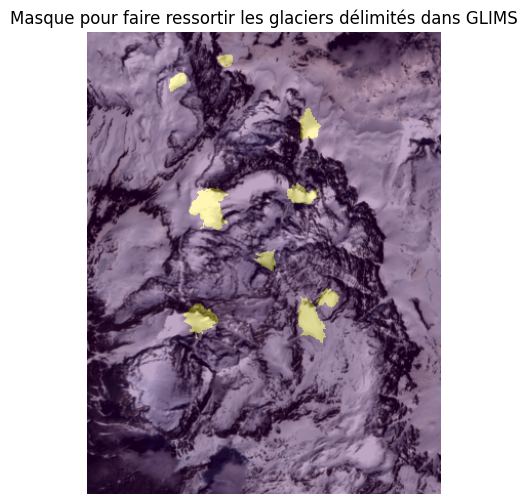

In [51]:
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.imshow(mask, alpha=0.35)   # overlay semi-transparent
plt.axis("off")
plt.title("Masque pour faire ressortir les glaciers délimités dans GLIMS")
plt.show()